# ISE 298
### TOPIC: AI DRIVEN SUPPLIER RISK PREDICTION AND MITIGATION DASHBOARD
### BY: DNYANESHWARI MADHAVRAO NARHARE
### STUDENT ID: 018207540
### PROJECT GUIDE: Prof. BEHIN ELAHI

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install shap
!pip install xgboost
import shap
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### PHASE 1: DATA ENGINEERING

In [5]:
# 1. Load Datasets
on_time_df = pd.read_csv(r'D:\DNYANESHWARI\Softwares\Anaconda\data\On time delivery.csv')
defects_df = pd.read_csv( r'D:\DNYANESHWARI\Softwares\Anaconda\data\defect rate or quality score.csv')
lead_time_df = pd.read_csv(r'D:\DNYANESHWARI\Softwares\Anaconda\data\lead time variability.csv')
esg_df = pd.read_csv( r'D:\DNYANESHWARI\Softwares\Anaconda\data\financial stability index ESG.csv')
geo_risk_df = pd.read_csv(r'D:\DNYANESHWARI\Softwares\Anaconda\data\Geopolitical risk.csv')

# 2. Synthesize Supplier Master Table (Mapping disparate datasets)
# We will use the ESG dataset as our base for 'Suppliers'
suppliers = esg_df[['name', 'ticker', 'total_score']].head(500).copy()
suppliers.columns = ['Supplier_Name', 'Ticker', 'Financial_Stability_Score']
suppliers['Supplier_ID'] = range(1, len(suppliers) + 1)

# Assign random countries from GeoRisk data for mapping
countries = geo_risk_df['Region'].unique()
np.random.seed(42)
suppliers['Country'] = np.random.choice(countries, size=len(suppliers))

# 3. Engineer KPIs
# On-Time Rate (from Logistics data)
on_time_kpi = on_time_df.groupby(on_time_df.index % 500)['Reached.on.Time_Y.N'].mean().reset_index()
on_time_kpi.columns = ['Supplier_ID', 'OnTime_Rate']
on_time_kpi['Supplier_ID'] += 1

# Defect Rate (from Manufacturing data)
defect_kpi = defects_df.groupby(defects_df.index % 500)['DefectRate'].mean().reset_index()
defect_kpi.columns = ['Supplier_ID', 'Defect_Rate']
defect_kpi['Supplier_ID'] += 1

# Lead Time Variability (Standard Deviation of Order Volume as proxy)
lead_time_kpi = lead_time_df.groupby(lead_time_df.index % 500)['OrderCount'].std().reset_index()
lead_time_kpi.columns = ['Supplier_ID', 'LeadTime_Variability']
lead_time_kpi['Supplier_ID'] += 1

# Geopolitical Risk Index (latest year from GeoRisk data)
geo_kpi = geo_risk_df[geo_risk_df['Year'] == geo_risk_df['Year'].max()][['Region', 'WRI']]
geo_kpi.columns = ['Country', 'Geopolitical_Risk_Index']

# 4. Merge into Master Table
master_df = suppliers.merge(on_time_kpi, on='Supplier_ID')\
                     .merge(defect_kpi, on='Supplier_ID')\
                     .merge(lead_time_kpi, on='Supplier_ID')\
                     .merge(geo_kpi, on='Country', how='left')

# Fill missing geo risks with median
master_df['Geopolitical_Risk_Index'] = master_df['Geopolitical_Risk_Index'].fillna(master_df['Geopolitical_Risk_Index'].median())


### PHASE 2: RISK SCORING & TARGET CREATION

In [6]:
scaler = MinMaxScaler()
cols_to_norm = ['OnTime_Rate', 'Defect_Rate', 'Financial_Stability_Score', 'Geopolitical_Risk_Index', 'LeadTime_Variability']
norm_data = scaler.fit_transform(master_df[cols_to_norm])
norm_df = pd.DataFrame(norm_data, columns=cols_to_norm)

# Formula: Higher OnTime/Financial is GOOD (invert them for RISK), Higher Defect/Geo/Var is BAD
# Risk = 0.3*(1-OnTime) + 0.25*Defect + 0.2* (1-Financial) + 0.15*Geo + 0.10*LeadTimeVar
master_df['Risk_Score'] = (
    0.30 * (1 - norm_df['OnTime_Rate']) +
    0.25 * norm_df['Defect_Rate'] +
    0.20 * (1 - norm_df['Financial_Stability_Score']) +
    0.15 * norm_df['Geopolitical_Risk_Index'] +
    0.10 * norm_df['LeadTime_Variability']
)

# Categorization
master_df['Risk_Level'] = pd.cut(master_df['Risk_Score'], 
                                bins=[0, 0.4, 0.7, 1.0], 
                                labels=['Low', 'Medium', 'High'])
# Target for ML
master_df['Is_High_Risk'] = (master_df['Risk_Score'] > 0.6).astype(int)

# 1. Calculate Average Values for Each Column
column_averages = master_df[cols_to_norm + ['Risk_Score']].mean()
print("--- GLOBAL KPI & RISK AVERAGES ---")
print(column_averages)

# 2. Country Analysis: Above or Below Average Risk
global_avg_risk = column_averages['Risk_Score']
country_analysis = master_df.groupby('Country')['Risk_Score'].mean().reset_index()
country_analysis.columns = ['Country', 'Country_Avg_Risk']

country_analysis['Risk_Status'] = country_analysis['Country_Avg_Risk'].apply(
    lambda x: '⚠️ ABOVE AVERAGE' if x > global_avg_risk else '✅ BELOW AVERAGE'
)

# 3. Country Ranking (Highest Risk to Lowest)
country_ranking = country_analysis.sort_values(by='Country_Avg_Risk', ascending=False).reset_index(drop=True)
country_ranking.insert(0, 'Rank', country_ranking.index + 1)

print("\n--- COUNTRY RISK RANKING (TOP 10 and BOTTOM 10) ---")
print(country_ranking.head(10))
print(country_ranking.tail(10))

# Export analysis to CSV for Power BI
country_ranking.to_csv('country_risk_analysis.csv', index=False)
column_averages.to_frame(name='Benchmark_Average').to_csv('global_benchmarks.csv')

--- GLOBAL KPI & RISK AVERAGES ---
OnTime_Rate                    0.596697
Defect_Rate                    2.749351
Financial_Stability_Score    999.992000
Geopolitical_Risk_Index        6.776300
LeadTime_Variability          23.371181
Risk_Score                     0.454711
dtype: float64

--- COUNTRY RISK RANKING (TOP 10 and BOTTOM 10) ---
   Rank                 Country  Country_Avg_Risk       Risk_Status
0     1               Guatemala          0.653454  ⚠️ ABOVE AVERAGE
1     2                Botswana          0.626973  ⚠️ ABOVE AVERAGE
2     3       Equatorial Guinea          0.607372  ⚠️ ABOVE AVERAGE
3     4  Ver. Arabische Emirate          0.601842  ⚠️ ABOVE AVERAGE
4     5    Russische Föderation          0.601439  ⚠️ ABOVE AVERAGE
5     6                   Qatar          0.600618  ⚠️ ABOVE AVERAGE
6     7                   Tonga          0.599943  ⚠️ ABOVE AVERAGE
7     8                 Denmark          0.596628  ⚠️ ABOVE AVERAGE
8     9                 Namibia          0.59

### Models used:

Logistic Regression :- Good baseline linear classifier

Random Forest :- Handles nonlinear patterns and reduces variance

XGBoost :- Advanced gradient boosting model (usually high performance)

### SHAP: SHapley Additive Explanations
Explain why model predicted high risk.

This is extremely good practice for business AI projects.

### PHASE 3: AI MODELING

In [7]:
X = master_df[cols_to_norm]
y = master_df['Is_High_Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    results[name] = roc_auc_score(y_test, probs)
    print(f"{name} ROC AUC: {results[name]:.4f}")

# Explain best model with SHAP
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name}")

explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)
shap_values_plot = shap_values[:, :, 1] if len(shap_values.values.shape) == 3 else shap_values

Logistic Regression ROC AUC: 0.9236
Random Forest ROC AUC: 0.9795
XGBoost ROC AUC: 0.9673

Best Model: Random Forest


### PHASE 4: VISUALIZATIONS

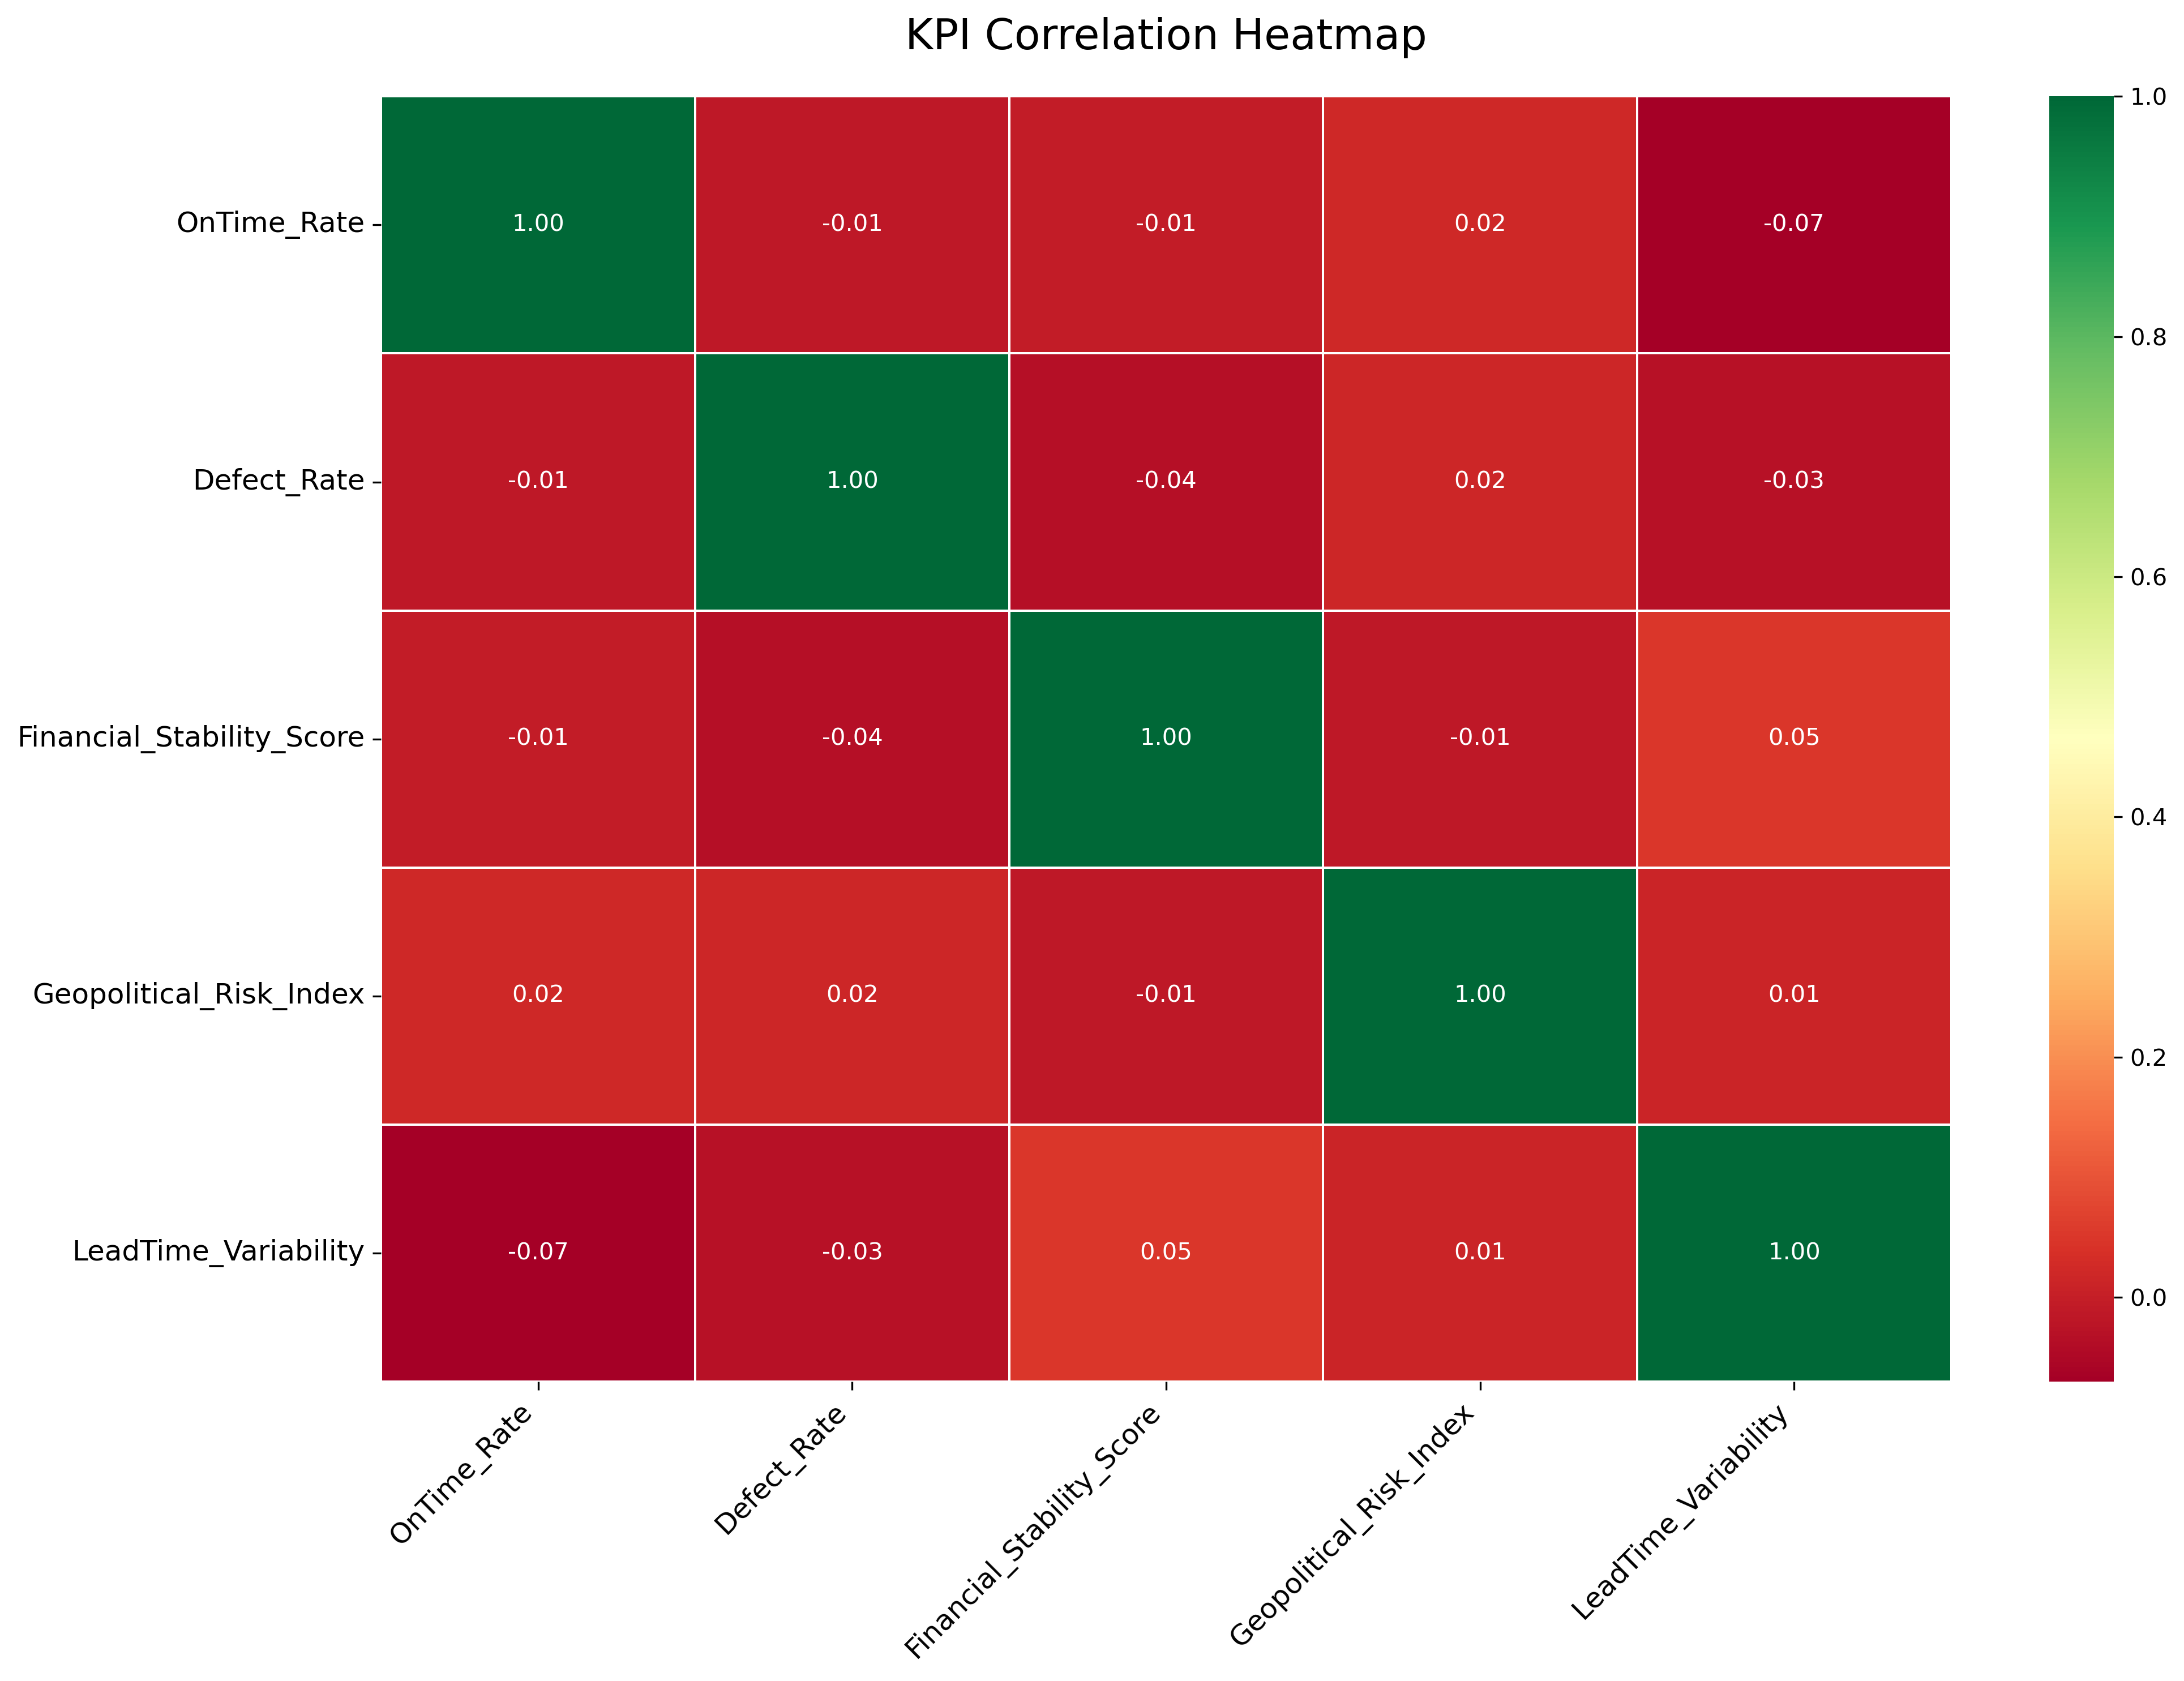

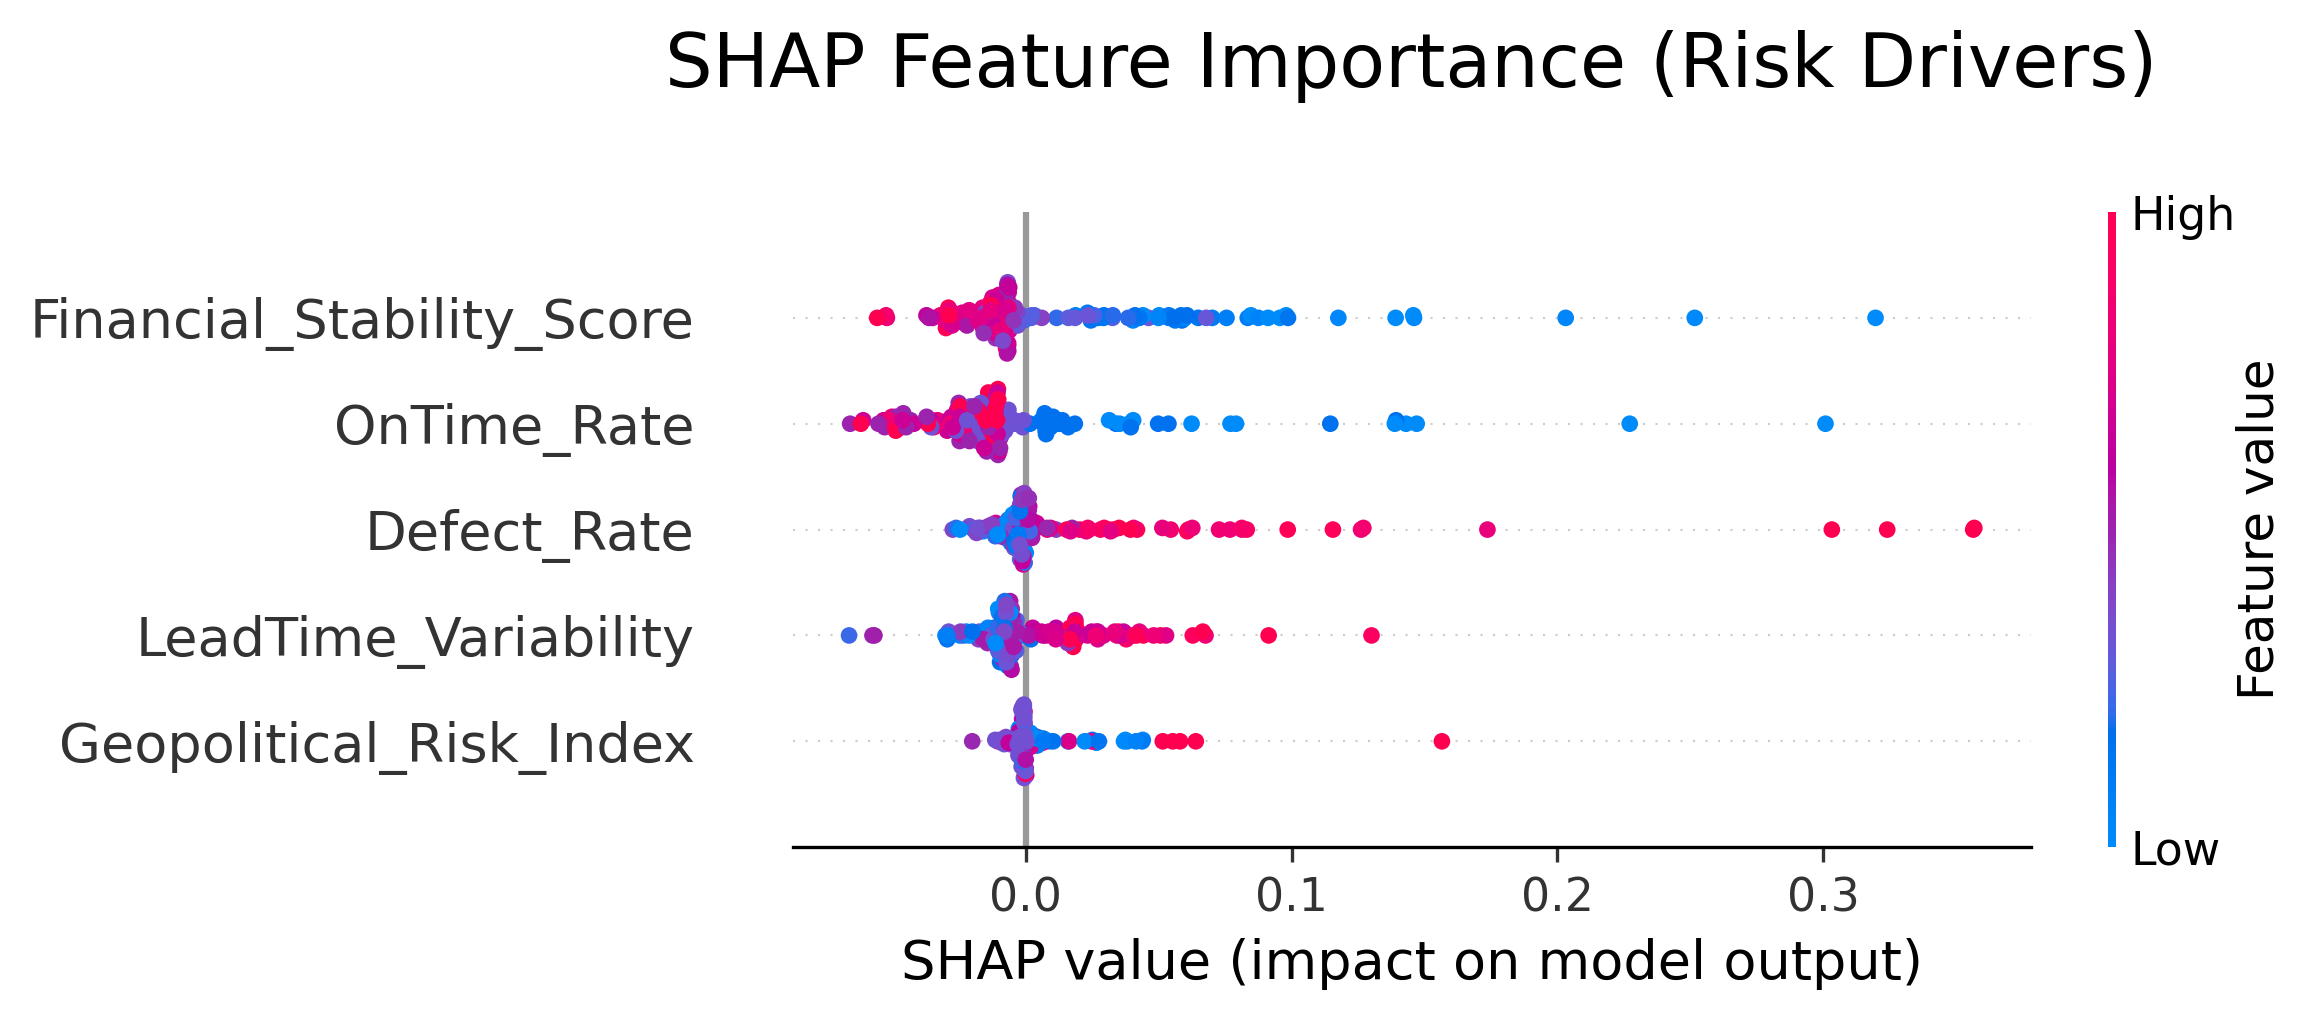


✅ PROJECT COMPLETE: 3 CSVs and 2 high-resolution Plots exported successfully.


In [8]:
# Correlation Heatmap
plt.figure(figsize=(14, 10), dpi=300)
sns.heatmap(
    master_df[cols_to_norm].corr(),
    annot=True,
    cmap='RdYlGn',
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 10}
)
plt.title("KPI Correlation Heatmap", fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight', pad_inches=0.5)
plt.show()

# SHAP Beeswarm Plot
plt.figure(figsize=(16, 12), dpi=300)
shap.plots.beeswarm(
    shap_values_plot,
    max_display=15,
    show=False # Required to save correctly afterwards
)
plt.title("SHAP Feature Importance (Risk Drivers)", fontsize=18, pad=30)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=300, bbox_inches='tight', pad_inches=0.5)
plt.show()

# Export Final Data for Power BI
master_df.to_csv('final_supplier_risk_data.csv', index=False)
country_ranking.to_csv('country_risk_analysis.csv', index=False)
column_averages.to_frame(name='Benchmark_Value').to_csv('global_averages.csv')

print("\n✅ PROJECT COMPLETE: 3 CSVs and 2 high-resolution Plots exported successfully.")